In [1]:
from pathlib import Path
from datetime import date, timedelta
import os
import re
import urllib.request

from pyhdf.SD import SD, SDC
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches


In [2]:
# Shared timeline for notebooks 01-04: 2022-05-01 through 2022-08-31.
START_DATE = date(2022, 5, 1)
END_DATE   = date(2022, 8, 31)
TILE = "h26v06"  # Bangladesh / NE India MODIS sinusoidal tile used in this workflow

UPDATE_DIR = Path("update")
HDF_DIR = UPDATE_DIR / "modis_hdf"
HDF_YEAR_DIR = HDF_DIR / str(START_DATE.year)
NC_DIR = UPDATE_DIR / "modis_netcdf"
HDF_YEAR_DIR.mkdir(parents=True, exist_ok=True)
NC_DIR.mkdir(parents=True, exist_ok=True)

BASE_URL = "https://ladsweb.modaps.eosdis.nasa.gov/archive/allData/61/MCDWD_L3"
LAADS_TOKEN = ""  # Optional: paste a temporary LAADS token here for this local run; keep blank before sharing.

def doy_range(start, end):
    current = start
    while current <= end:
        yield current, f"{current.timetuple().tm_yday:03d}"
        current += timedelta(days=1)

def find_lads_file(day):
    doy = f"{day.timetuple().tm_yday:03d}"
    url = f"{BASE_URL}/{day.year}/{doy}/"
    html = urllib.request.urlopen(url, timeout=60).read().decode("utf-8", errors="ignore")
    pattern = rf"MCDWD_L3\.A{day.year}{doy}\.{TILE}\.061\.[0-9]+\.hdf"
    match = re.search(pattern, html)
    if not match:
        raise FileNotFoundError(f"No {TILE} MCDWD file listed for {day.isoformat()}")
    return url + match.group(0), HDF_YEAR_DIR / match.group(0)

def download_day(day):
    url, path = find_lads_file(day)
    if path.exists() and path.stat().st_size > 100_000:
        print(f"cache hit -> {path.name}")
        return path
    token = (LAADS_TOKEN or os.environ.get("LAADS_TOKEN", "")).strip()
    if not token:
        raise RuntimeError(
            "LAADS_TOKEN is not set. Create a LAADS/Earthdata download token, then run:\n"
            "  export LAADS_TOKEN='your_token_here'\n"
            "or paste it into the blank LAADS_TOKEN variable in this cell for a local run, "
            "or download the HDFs in a browser and place them in update/modis_hdf/."
        )
    print(f"downloading {day.isoformat()} -> {path.name}")
    req = urllib.request.Request(url, headers={"Authorization": f"Bearer {token}"})
    with urllib.request.urlopen(req, timeout=180) as response:
        content_type = response.headers.get("Content-Type", "")
        payload = response.read()
    if b"<!DOCTYPE html" in payload[:200] or "text/html" in content_type.lower() or len(payload) < 100_000:
        raise RuntimeError(
            f"LAADS did not return an HDF for {day.isoformat()} (content-type={content_type}, bytes={len(payload)}). "
            "Check token validity and dataset licence acceptance."
        )
    path.write_bytes(payload)
    print(f"downloaded {path.name} ({path.stat().st_size/1e6:.1f} MB)")
    return path

# Keep this small by default. Set DOWNLOAD_ALL_DAYS=True to pull every daily HDF for May-August
# (~123 files, roughly 1.1 GB before NetCDF conversion).
DOWNLOAD_ALL_DAYS = False
SAMPLE_DATES = [date(2022, 5, 1), date(2022, 6, 15), date(2022, 7, 15), date(2022, 8, 31)]

dates_to_download = [d for d, _ in doy_range(START_DATE, END_DATE)] if DOWNLOAD_ALL_DAYS else SAMPLE_DATES
existing_2022 = sorted(HDF_DIR.glob("MCDWD_L3.A2022*.h26v06*.hdf")) + sorted(HDF_YEAR_DIR.glob("MCDWD_L3.A2022*.h26v06*.hdf"))
if existing_2022 and not DOWNLOAD_ALL_DAYS:
    hdf_files = existing_2022
    print(f"using {len(hdf_files)} existing 2022 HDF file(s) from {HDF_DIR} or {HDF_YEAR_DIR}")
else:
    hdf_files = [download_day(d) for d in dates_to_download]

assert hdf_files, "No 2022 MCDWD HDF files found."
file_path = str(hdf_files[0])
hdf = SD(file_path, SDC.READ)
print(f"Opened for inspection: {file_path}")


In [3]:
# List datasets inside the first file, then export the selected dates to NetCDF.
print("Datasets:", list(hdf.datasets().keys()))

flood_layers = ["Flood_1Day_250m", "Flood_2Day_250m", "Flood_3Day_250m"]

for layer_name in flood_layers:
    layer = hdf.select(layer_name)
    arr = layer[:]
    print(f"
{layer_name}")
    print(f"  Shape: {arr.shape}")
    print(f"  Unique values: {np.unique(arr)}")
    print(f"  Attributes: {layer.attributes()}")

# Read one layer for the map below.
data = hdf.select("Flood_3Day_250m")[:].astype(float)
hdf.end()

# Convert downloaded HDF files to per-day NetCDF files for later work.
def hdf_to_netcdf(hdf_path):
    hdf_path = Path(hdf_path)
    out = NC_DIR / hdf_path.with_suffix(".nc").name
    if out.exists():
        return out
    f = SD(str(hdf_path), SDC.READ)
    arrays = {name: f.select(name).get().astype("uint8") for name in flood_layers}
    f.end()
    fname = hdf_path.name
    parts = fname.split(".")
    day = date(int(parts[1][1:5]), 1, 1) + timedelta(days=int(parts[1][5:8]) - 1)
    ds_out = xr.Dataset(
        {name: (("y", "x"), arr) for name, arr in arrays.items()},
        coords={"y": np.arange(arrays[flood_layers[0]].shape[0]), "x": np.arange(arrays[flood_layers[0]].shape[1])},
        attrs={
            "source": "NASA LAADS MCDWD_L3 historical MODIS flood product",
            "date": day.isoformat(),
            "tile": TILE,
            "classes": "0=no water, 1=surface/reference water, 2=recurring flood, 3=flood, 255=no data/cloud",
        },
    )
    encoding = {name: {"zlib": True, "complevel": 4, "dtype": "uint8"} for name in flood_layers}
    ds_out.to_netcdf(out, engine="h5netcdf", encoding=encoding)
    return out

nc_files = [hdf_to_netcdf(p) for p in hdf_files]
print("
NetCDF files ready:")
for p in nc_files:
    print(" ", p)


Datasets: ['FloodCS_1Day_250m', 'Flood_1Day_250m', 'Flood_2Day_250m', 'Flood_3Day_250m', 'TotalCounts_1Day_250m', 'TotalCounts_2Day_250m', 'TotalCounts_3Day_250m', 'ValidCountsCS_1Day_250m', 'ValidCounts_1Day_250m', 'ValidCounts_2Day_250m', 'ValidCounts_3Day_250m', 'WaterCountsCS_1Day_250m', 'WaterCounts_1Day_250m', 'WaterCounts_2Day_250m', 'WaterCounts_3Day_250m']

Flood_1Day_250m
  Shape: (4800, 4800)
  Unique values: [  0   1   2   3 255]
  Attributes: {'_FillValue': 255, 'valid_range': [0, 3], 'scale_factor': 1.0, 'add_offset': 0.0, 'long_name': 'Combined Terra and Aqua MODIS Flood_1Day_250m', 'units': 'none', 'description': '\n1 day flood pixels detected from Terra and Aqua\n  no clouds removed\n  terrain shadow pixels masked\n  HAND pixels masked\n  threshold from table, minimum of 1\nFlag values:\n    255 : Insufficient data\n    0 : No water\n    1 : Water (matches standard reference water)\n    2 : Recurring flood (expected seasonal flood)\n    3 : Flood (unusual)\n'}

Flood_2

In [4]:

# ── 2. Mask fill value ────────────────────────────────────────────────────────
data[data == 255] = np.nan

# ── 3. Parse filename
fname = file_path.split('/')[-1]
parts = fname.split('.')

date_part = parts[1]             
year      = int(date_part[1:5])  
doy       = int(date_part[5:8])  

tile = parts[2]                 
h    = int(tile[1:3])            
v    = int(tile[4:6])         

print(f"Tile: {tile.upper()}  |  Year: {year}  |  DOY: {doy}")

Tile: H26V06  |  Year: 2004  |  DOY: 213


In [5]:

# ── 4. Compute lat/lon grid from MODIS sinusoidal tile formula ────────────────
R          = 6371007.181            # MODIS Earth radius (m)
tile_size  = np.radians(10.0) * R  # 10° tile in metres
pixel_size = tile_size / 4800      # 250 m nominal

# Upper-left sinusoidal corner (pixel centre)
x_ul = (h - 18) * tile_size + 0.5 * pixel_size
y_ul = (9  -  v) * tile_size - 0.5 * pixel_size

# 1-D coordinate arrays along each axis
x_sin = x_ul + np.arange(4800) * pixel_size   # (4800,)
y_sin = y_ul - np.arange(4800) * pixel_size   # (4800,)

# Convert sinusoidal → lat / lon
lat_1d = np.degrees(y_sin / R)                # (4800,)
lon_2d = np.degrees(                           # (4800, 4800)
    x_sin[np.newaxis, :] / (R * np.cos(np.radians(lat_1d[:, np.newaxis])))
)
lat_2d = np.tile(lat_1d[:, np.newaxis], (1, 4800))

# Mask pixels outside ±180 lon (sinusoidal edge artefacts)
data[np.abs(lon_2d) > 180] = np.nan

# ── 5. Downsample 4800×4800 → 480×480 for fast plotting ──────────────────────
step     = 10
data_ds  = data  [::step, ::step]
lat_ds   = lat_2d[::step, ::step]
lon_ds   = lon_2d[::step, ::step]

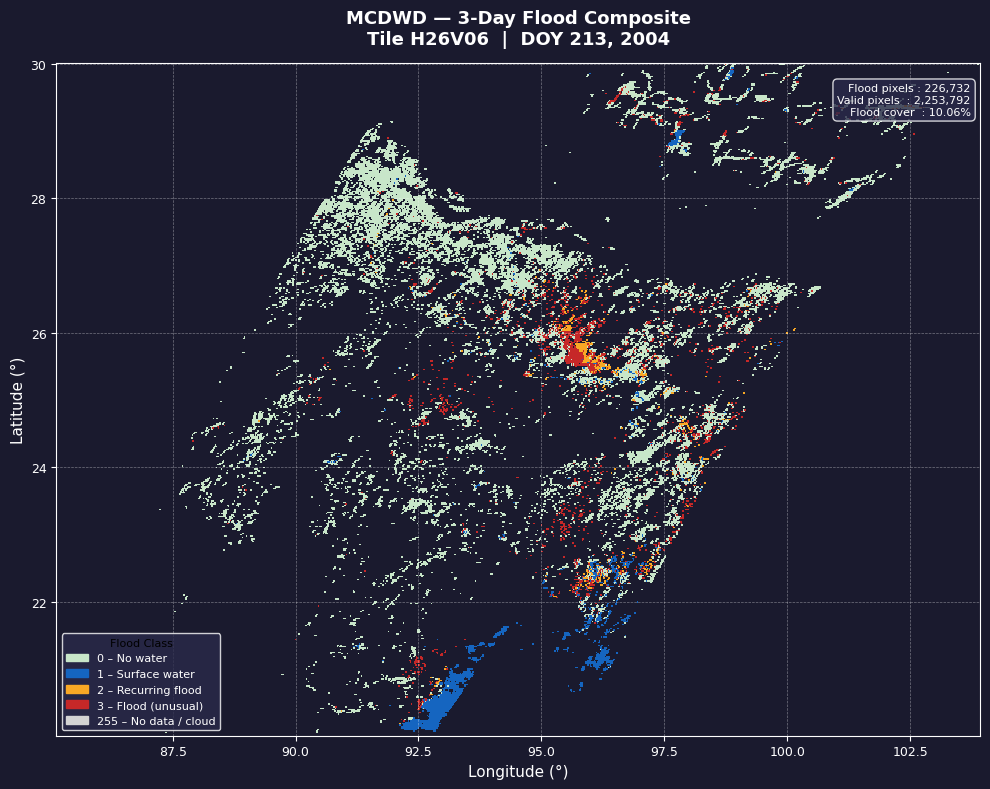

In [6]:

# ── 6. Discrete colormap ──────────────────────────────────────────────────────
colors = ['#c8e6c9', '#1565c0', '#f9a825', '#c62828']
cmap   = mcolors.ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm   = mcolors.BoundaryNorm(bounds, cmap.N)

legend_patches = [
    mpatches.Patch(color='#c8e6c9', label='0 – No water'),
    mpatches.Patch(color='#1565c0', label='1 – Surface water'),
    mpatches.Patch(color='#f9a825', label='2 – Recurring flood'),
    mpatches.Patch(color='#c62828', label='3 – Flood (unusual)'),
    mpatches.Patch(color='lightgrey', label='255 – No data / cloud'),
]
# ── 7. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8), facecolor='#1a1a2e')
ax.set_facecolor('#1a1a2e')

pcm = ax.pcolormesh(
    lon_ds, lat_ds, data_ds,
    cmap=cmap, norm=norm,
    shading='auto'
)

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.4, color='white')
ax.tick_params(colors='white', labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor('white')

ax.set_xlabel('Longitude (°)', color='white', fontsize=11)
ax.set_ylabel('Latitude (°)',  color='white', fontsize=11)
ax.set_title(
    f'MCDWD — 3-Day Flood Composite\n'
    f'Tile {tile.upper()}  |  DOY {doy}, {year}',
    color='white', fontsize=13, fontweight='bold', pad=14
)

ax.legend(
    handles=legend_patches,
    loc='lower left', fontsize=8,
    facecolor='#2a2a4a', edgecolor='white',
    labelcolor='white',
    title='Flood Class', title_fontsize=8
)

# ── 8. Stats annotation ───────────────────────────────────────────────────────
total   = np.sum(~np.isnan(data))
flooded = np.sum(data == 3)
pct     = 100 * flooded / total if total > 0 else 0

ax.text(
    0.99, 0.97,
    f'Flood pixels : {flooded:,}\n'
    f'Valid pixels  : {total:,}\n'
    f'Flood cover  : {pct:.2f}%',
    transform=ax.transAxes, ha='right', va='top',
    color='white', fontsize=8,
    bbox=dict(facecolor='#2a2a4a', edgecolor='white', alpha=0.8, boxstyle='round,pad=0.4')
)

plt.tight_layout()

plt.show()